Thrust lapse factor for climb: 0.6910
Thrust lapse factor for cruise: 0.2069


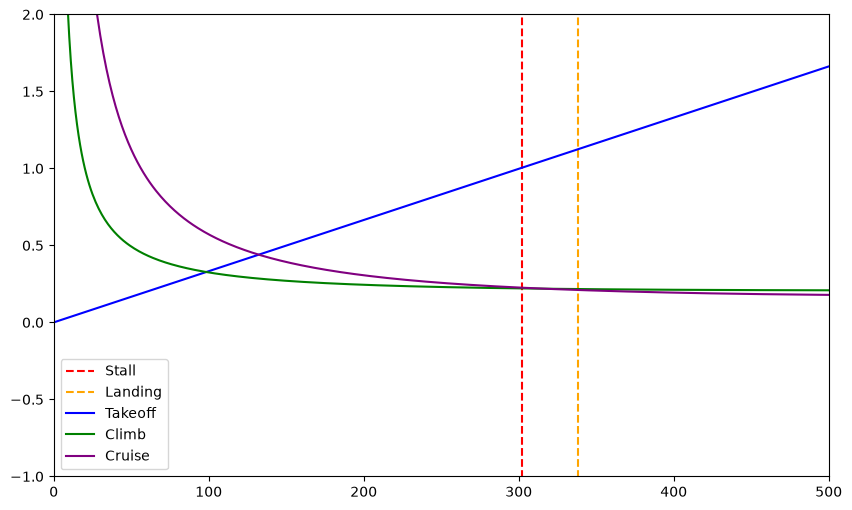

In [53]:
import numpy as np
import matplotlib.pyplot as plt

C_D0 = 0.01099 #Needs to be estimated from VSP
C_Lmax = 1.3 #Needs to be estimated from data
C_LTO = C_Lmax / 1.21 
e = 0.8 # Oswald efficiency factor, needs to be estimated from data
AR = 10 # Aspect ratio
v_app = 146 #kts 
M_cruise = 0.85 #Cruise Mach number
M_climb = 0.4 #Climb Mach number
ROC = 2800 *0.3048 # [m/min] 
q_climb = 0.5 * 1.1721 * (M_climb * 338.55)**2 # Dynamic pressure at climb [N/m^2] Density and speed of sound at 1500 ft altitude
q_cruise = 0.5 * 0.3796 * (M_cruise * 296.5)**2 # Dynamic pressure at cruise [N/m^2] Density and speed of sound at 35000 ft altitude

LFL = 2300 # Landing field length FAR25 [m]
S_landing = LFL/1.67  # Landing field length FAR25 [m]
v_stall = v_app / 1.23 #Stall speed [kts]
TOP = 280 # Approximated from Raymer graph 
W_LANDINGW0 = 0.8513 #Landing weight fraction, value from calculations.ipynb
W_CRUISEW0 = 0.8560 #Cruise weight fraction, value from calculations.ipynb
W_CLIMBW0 = 0.9813 # Climb weight fraction, value from calculations.ipynb

#THRUST LAPSE MODEL - Mattingly. Assuming TR = 1.0, check lower or higher for sensitivity. 

def thrust_lapse_mattingly(M, T, p, TR=1.0):
    gamma = 1.4
    T_sealevel = 288.15 #K
    p_sealevel = 101325 #Pa

    theta = T / T_sealevel
    delta = p / p_sealevel

    theta_0 = theta * (1 + (gamma - 1) / 2 * M**2)
    delta_0 = delta * (1 + (gamma - 1) / 2 * M**2)**(gamma / (gamma - 1))

    if theta_0 <= TR:
        thrust_lapse =  delta_0 * (1 - 0.49 * M**(0.5))
    else:
        thrust_lapse = delta_0 * (1 - (0.49 * M**(0.5)) - (3 * (theta_0 - TR) / (1.5 + M)))

    return thrust_lapse


# STALL WING LOADING

def WS_STALL(v_stall, C_Lmax):
    return 0.5 * (1/9.82) * 1.225 * (v_stall * 0.5144)**2 * C_Lmax


# LANDING WING LOADING

WS_LANDING = (S_landing - 305) * C_Lmax / 4.84  #Assuming density ratio of 1.0, obstacle clearance of 305 m. 

WS_LANDING_TO = WS_LANDING / W_LANDINGW0


# TAKEOFF THRUST TO WEIGHT
# Eyeball TOP from Raymer graph. Assuming density ratio of 1.0

def TW_TO(WS, TOP, C_LTO):
    return WS / (TOP * 1 * C_LTO)

# CLIMB THRUST TO WEIGHT

T_climbT_SL = thrust_lapse_mattingly(M_climb, 285.68, 95952.5, TR=1.0) # Thrust lapse factor for climb, assuming TR = 1.0
print(f"Thrust lapse factor for climb: {T_climbT_SL:.4f}")

def TW_CLIMB(WS, q_climb, C_D0, e, AR):
    return ((q_climb * C_D0 / (WS * 9.82)) + (WS * 9.82 / (q_climb * np.pi * e * AR)) + np.sin(np.deg2rad(6))) * (1/T_climbT_SL) * W_CLIMBW0 # 6 degree climb angle, assuming V is total airspeed and V = 0.4*a





# CRUISE THRUST TO WEIGHT

T_cruiseT_SL = thrust_lapse_mattingly(M_cruise, 218.81, 23842, TR=1.0)
print(f"Thrust lapse factor for cruise: {T_cruiseT_SL:.4f}")

def TW_CRUISE(WS, q_cruise, C_D0, e, AR):
    return ((q_cruise * C_D0 / (WS * 9.82)) + (WS * 9.82 / (q_cruise * np.pi * e * AR))) * (1/T_cruiseT_SL) * W_CRUISEW0

# Thrust lapse factor for cruise, assuming TR = 1.0





# INSTANTANEOUS TURN THRUST TO WEIGHT


# SUSTAINED TURN THRUST TO WEIGHT





# Plotting the constraint analysis

WS = np.linspace(0.01, 10000, 10000) # Wing loading range

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 500)
ax.set_ylim(-1, 2)
# WS stall will be a vertical line
ax.plot([WS_STALL(v_stall, C_Lmax), WS_STALL(v_stall, C_Lmax)], [-10, 100], label='Stall', color='red', linestyle='--')
ax.plot([WS_LANDING_TO, WS_LANDING_TO], [-10, 100], label='Landing', color='orange', linestyle='--')
ax.plot(WS, TW_TO(WS, TOP, C_LTO), label='Takeoff', color='blue', linestyle='-')
ax.plot(WS, TW_CLIMB(WS, q_climb, C_D0, e, AR), label='Climb', color='green', linestyle='-')
ax.plot(WS, TW_CRUISE(WS, q_cruise, C_D0, e, AR), label='Cruise', color='purple', linestyle='-')

ax.legend()